In [1]:
# Análise de Padrões de Fraude — VoughtGuard
#
# Investigação dos padrões de fraude no dataset PaySim, usando o pipeline
# de limpeza e transformação já validado, para embasar as tabelas
# analíticas entregues ao time de risco.

In [2]:
%matplotlib inline
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import limpeza, transformacao, qualidade, tabelas_analiticas as ta

sns.set_style("whitegrid")

In [3]:
df = limpeza.carregar_dados("../data/raw/transactions.csv")
df = limpeza.limpar_dados(df)
df = transformacao.aplicar_transformacoes(df)
print(f"Shape final: {df.shape}")

Shape final: (6362604, 16)


In [4]:
# ## 1. Onde a fraude se concentra?


In [5]:
ranking = ta.ranking_tipo_transacao_fraude(df)
ranking

,type,total_transacoes,total_fraudes,valor_total_movimentado,taxa_fraude_pct
0,TRANSFER,532909,4097,4.852920e+11,0.7688
1,CASH_OUT,2237484,4100,3.944130e+11,0.1832
2,CASH_IN,1399284,0,2.363674e+11,0.0000
3,DEBIT,41432,0,2.271992e+08,0.0000
4,PAYMENT,2151495,0,2.809337e+10,0.0000


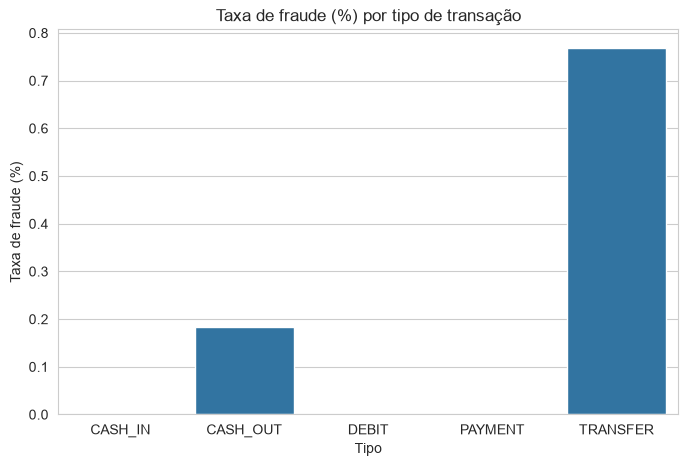

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=ranking, x="type", y="taxa_fraude_pct")
plt.title("Taxa de fraude (%) por tipo de transação")
plt.ylabel("Taxa de fraude (%)")
plt.xlabel("Tipo")
plt.show()

In [7]:
# **Achado:** a fraude está 100% concentrada em `TRANSFER` e `CASH_OUT`.
# Os tipos `PAYMENT`, `CASH_IN` e `DEBIT` não apresentam nenhum caso na base.
# Isso sugere que um modelo ou regra de negócio poderia, com segurança,
# aplicar verificações mais rígidas apenas nesses dois tipos, sem gerar
# atrito para os demais.

In [8]:
# ## 2. O sistema de alerta atual está funcionando?


In [9]:
divergencia = qualidade.calcular_divergencia_flag(df)
divergencia

{'total_fraudes': 8197,
 'fraudes_nao_sinalizadas': 8181,
 'pct_fraudes_nao_sinalizadas': 99.8}

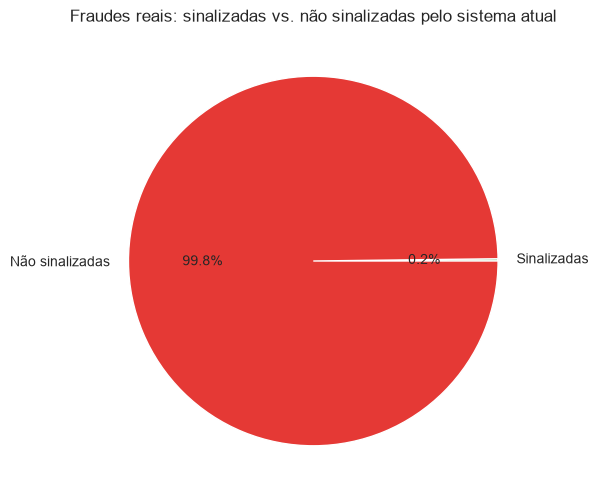

In [10]:
labels = ["Sinalizadas", "Não sinalizadas"]
valores = [
    divergencia["total_fraudes"] - divergencia["fraudes_nao_sinalizadas"],
    divergencia["fraudes_nao_sinalizadas"],
]

plt.figure(figsize=(6, 6))
plt.pie(valores, labels=labels, autopct="%1.1f%%", colors=["#4CAF50", "#E53935"])
plt.title("Fraudes reais: sinalizadas vs. não sinalizadas pelo sistema atual")
plt.show()

In [11]:
print(
    f"Achado principal do projeto: de {divergencia['total_fraudes']} fraudes reais, "
    f"{divergencia['fraudes_nao_sinalizadas']} "
    f"({divergencia['pct_fraudes_nao_sinalizadas']}%) passaram sem qualquer alerta "
    f"do sistema atual (isFlaggedFraud). Isso evidencia a necessidade de regras "
    f"ou modelos mais sensíveis do que o critério atual.")

Achado principal do projeto: de 8197 fraudes reais, 8181 (99.8%) passaram sem qualquer alerta do sistema atual (isFlaggedFraud). Isso evidencia a necessidade de regras ou modelos mais sensíveis do que o critério atual.


In [12]:
# ## 3. O padrão de saldo zerado é um bom indicador de fraude?


In [13]:
tabela_cruzada=pd.crosstab(
    df["saldo_origem_zerado_suspeito"], df["isFraud"], normalize="index"
) * 100
tabela_cruzada.columns = ["Não fraude (%)", "Fraude (%)"]
tabela_cruzada

,Não fraude (%),Fraude (%)
saldo_origem_zerado_suspeito,,
False,99.808781,0.191219
True,99.998803,0.001197


In [14]:
taxa_fraude_com_flag = tabela_cruzada.loc[True, "Fraude (%)"] if True in tabela_cruzada.index else None
taxa_fraude_sem_flag = tabela_cruzada.loc[False, "Fraude (%)"] if False in tabela_cruzada.index else None

print(
    f"Taxa de fraude quando saldo_origem_zerado_suspeito=True: {taxa_fraude_com_flag:.2f}%\n"
    f"Taxa de fraude quando saldo_origem_zerado_suspeito=False: {taxa_fraude_sem_flag:.2f}%\n\n"
    f"Achado: apesar de parecer um sinal forte, essa flag tem baixo poder "
    f"discriminante nesse dataset — contas de merchant (que recebem grande parte "
    f"das transações) legitimamente não possuem saldo rastreado, gerando muitos "
    f"falsos positivos. Não deve ser usado isoladamente como regra de fraude.")


Taxa de fraude quando saldo_origem_zerado_suspeito=True: 0.00%
Taxa de fraude quando saldo_origem_zerado_suspeito=False: 0.19%

Achado: apesar de parecer um sinal forte, essa flag tem baixo poder discriminante nesse dataset — contas de merchant (que recebem grande parte das transações) legitimamente não possuem saldo rastreado, gerando muitos falsos positivos. Não deve ser usado isoladamente como regra de fraude.


In [15]:
# ## 4. Faixas de valor e fraude


In [16]:
fraude_por_faixa = (
    df.groupby("faixa_valor", observed=True)["isFraud"].mean() * 100
).round(4)
fraude_por_faixa

faixa_valor
baixo         0.0294
medio         0.0192
alto          0.0638
muito_alto    0.2293
Name: isFraud, dtype: float64

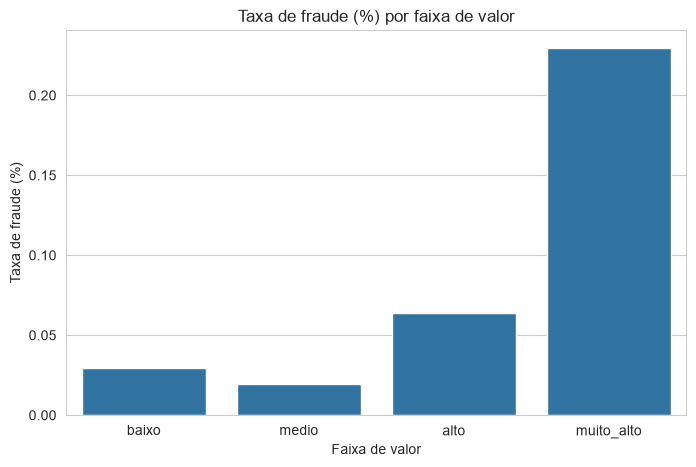

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(x=fraude_por_faixa.index, y=fraude_por_faixa.values)
plt.title("Taxa de fraude (%) por faixa de valor")
plt.ylabel("Taxa de fraude (%)")
plt.xlabel("Faixa de valor")
plt.show()

In [18]:
# ## Conclusões
#
# 1. Fraude está inteiramente restrita a `TRANSFER` e `CASH_OUT`.
# 2. O sistema de alerta atual (`isFlaggedFraud`) captura menos de 1% das
#    fraudes reais — é essencialmente inoperante.
# 3. A flag de saldo zerado, isoladamente, não discrimina bem fraude.
# 4. Recomenda-se, como próximo passo, treinar um modelo supervisionado
#    (ex: Random Forest ou XGBoost) usando `type`, `amount`, `erro_saldo_origem`
#    e `erro_saldo_destino` como features, restrito a `TRANSFER`/`CASH_OUT`.